<a href="https://colab.research.google.com/github/be-ayush/ai-ml-learning/blob/main/HOML/HOML3_Chapter6_EnsembleLearning_RandomForests.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.datasets import make_moons
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

X, y = make_moons(n_samples=5000, noise=0.30, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

voting_classifier = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression()),
        ('rf', RandomForestClassifier()),
        ('svc', SVC())
    ]
)

voting_classifier.fit(X_train, y_train)

VotingClassifier(estimators=[('lr', LogisticRegression()),
                             ('rf', RandomForestClassifier()), ('svc', SVC())])

In [2]:
for name, classifier in voting_classifier.named_estimators_.items():
  print(name + ":", classifier.score(X_test, y_test))


lr: 0.8616
rf: 0.9096
svc: 0.9088


In [3]:
voting_classifier.predict(X_test[:1])

array([0])

In [4]:
[clf.predict(X_test[:1]) for clf in voting_classifier.estimators_]

[array([0]), array([0]), array([0])]

In [5]:
voting_classifier.score(X_test, y_test)

0.9128

In [6]:
voting_classifier.voting = 'soft'
voting_classifier.named_estimators['svc'].probability = True
voting_classifier.fit(X_train, y_train)
voting_classifier.score(X_test, y_test)

0.9144

In [7]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

# bootstrap = False for pasting
bag_classifier = BaggingClassifier(DecisionTreeClassifier(), n_estimators = 500, max_samples = 100, n_jobs = -1, random_state = 42, oob_score=True)
bag_classifier.fit(X_train, y_train)
bag_classifier.oob_score_

0.9064

In [8]:
from sklearn.ensemble import RandomForestClassifier

random_forest_classifier = RandomForestClassifier(n_estimators = 500, max_leaf_nodes = 16, n_jobs = -1, random_state = 42)
random_forest_classifier.fit(X_train, y_train)
random_forest_classifier.score(X_test, y_test)

0.916

In [9]:
eq_bagging_classifier = BaggingClassifier(DecisionTreeClassifier(max_features='sqrt', max_leaf_nodes = 16), n_estimators = 500, n_jobs = -1, random_state = 42)
eq_bagging_classifier.fit(X_train, y_train)
eq_bagging_classifier.score(X_test, y_test)

0.916

In [10]:
from sklearn.datasets import load_iris

iris = load_iris(as_frame = True)
iris_rnd_forest = RandomForestClassifier(n_estimators = 500, n_jobs = -1, random_state = 42)
iris_rnd_forest.fit(iris.data, iris.target)

for score, name in zip(iris_rnd_forest.feature_importances_, iris.data.columns):
  print(name, score)

sepal length (cm) 0.11249225099876375
sepal width (cm) 0.02311928828251033
petal length (cm) 0.4410304643639577
petal width (cm) 0.4233579963547682


In [11]:
from sklearn.ensemble import AdaBoostClassifier

ada_classifier = AdaBoostClassifier(
    DecisionTreeClassifier(max_depth = 1),
    n_estimators = 200,
    learning_rate = 0.5,
    random_state = 42,
    algorithm = 'SAMME'
)
ada_classifier.fit(X_train, y_train)
ada_classifier.score(X_test, y_test)

/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


0.904

In [12]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor

m = 100
rng = np.random.default_rng(42)
X = rng.random((m, 1)) - 0.5
noise = 0.05 * rng.standard_normal(m)
y = 3*X[:, 0] ** 2 + noise

tree_regressor1 = DecisionTreeRegressor(max_depth = 2, random_state = 42)
tree_regressor1.fit(X, y)

DecisionTreeRegressor(max_depth=2, random_state=42)

In [13]:
y2 = y - tree_regressor1.predict(X)
tree_regressor2 = DecisionTreeRegressor(max_depth = 2, random_state = 43)
tree_regressor2.fit(X, y2)

DecisionTreeRegressor(max_depth=2, random_state=43)

In [14]:
y3 = y2 - tree_regressor2.predict(X)
tree_regressor3 = DecisionTreeRegressor(max_depth = 2, random_state = 44)
tree_regressor3.fit(X, y3)

DecisionTreeRegressor(max_depth=2, random_state=44)

In [15]:
X_new = np.array([[-0.4], [0.], [0.5]])
sum(tree.predict(X_new) for tree in (tree_regressor1, tree_regressor2, tree_regressor3))

array([0.57356534, 0.0405142 , 0.66914249])

In [16]:
from sklearn.ensemble import GradientBoostingRegressor

gradient_boosting_regressor = GradientBoostingRegressor(n_estimators = 3, max_depth = 2, learning_rate = 1.0, random_state=42)

In [17]:
gradient_boosting_regressor.fit(X, y)
gradient_boosting_regressor.score(X, y)

0.9115260090439279

In [18]:
gradient_boosting_early_stop = GradientBoostingRegressor(n_estimators = 1000, max_depth = 2, learning_rate = 0.1, n_iter_no_change=5, random_state = 42)
gradient_boosting_early_stop.fit(X, y)

GradientBoostingRegressor(max_depth=2, n_estimators=1000, n_iter_no_change=5,
                          random_state=42)

In [19]:
gradient_boosting_early_stop.n_estimators_

26

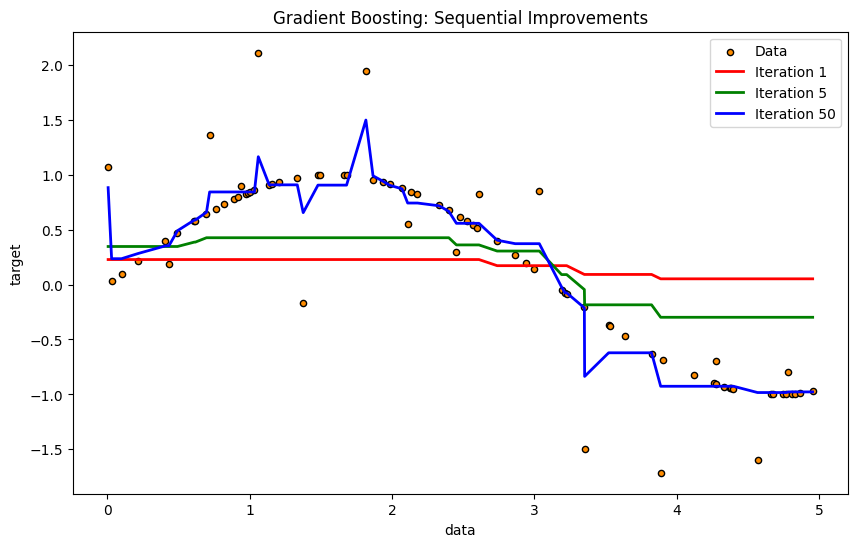

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor

# Generate synthetic data (Sine wave)
X = np.sort(5 * np.random.rand(80, 1), axis=0)
y = np.sin(X).ravel()
y[::5] += 3 * (0.5 - np.random.rand(16)) # Add noise

# Simple Gradient Boosting Implementation
n_estimators = 50
learning_rate = 0.1
models = []

# Step 1: Initialize with mean
F_0 = np.mean(y)
residuals = y - F_0
F_m = np.full_like(y, F_0)

preds_at_steps = []

# Step 2: Iterate
for i in range(n_estimators):
    # Fit tree to residuals
    tree = DecisionTreeRegressor(max_depth=2)
    tree.fit(X, residuals)

    # Update prediction
    update = tree.predict(X)
    F_m += learning_rate * update
    residuals = y - F_m

    if i+1 in [1, 5, 50]:
        preds_at_steps.append((i+1, F_m.copy()))

# Visualization code
plt.figure(figsize=(10, 6))
plt.scatter(X, y, s=20, edgecolor="black", c="darkorange", label="Data")

colors = ['r', 'g', 'b']
for idx, (step, pred) in enumerate(preds_at_steps):
    plt.plot(X, pred, color=colors[idx], label=f"Iteration {step}", linewidth=2)

plt.xlabel("data")
plt.ylabel("target")
plt.title("Gradient Boosting: Sequential Improvements")
plt.legend()
plt.show()

In [22]:
from sklearn.ensemble import StackingClassifier

stacking_classifier = StackingClassifier(
    estimators = [
        ('lr', LogisticRegression(random_state = 42)),
        ('rf', RandomForestClassifier(random_state = 42)),
        ('svc', SVC(random_state = 42))
    ],
    final_estimator = RandomForestClassifier(random_state = 43),
    cv = 5
)

stacking_classifier.fit(X_train, y_train)
stacking_classifier.score(X_test, y_test)

0.9056